In [1]:
!pip install -Uq pymcel scipy rebound

In [2]:
import rebound as rb
import numpy as np
import pymcel as pc
import matplotlib.pyplot as plt
import plotly.io as pio

Bienvenido a PyMCel v0.9.21 ¡al infinito y más allá!


## Hohmann Transfer

Values are defined for $r_1$ and $r_2$, along with other necessary data:

In [3]:
r1 = 6378 + 480
r2 = 6378 + 16000

The simulation is initialized:

In [4]:
sim = rb.Simulation()
sim.units = 'km', 's', 'kg'

In [5]:
mu = sim.G * pc.constantes.M_earth

The velocities are defined:

In [6]:
v1 = (mu / r1)**0.5
delta_v1  =  ((mu / r1)**0.5) * (((2 * r2) / (r1 + r2))**0.5 - 1)
v2  =  ((mu / r2)**0.5) * (((2 * r1) / (r1 + r2))**0.5)

Satellite positions and velocities:

In [7]:
x1 = r1
y1 = 0
z1 = 0

In [8]:
vx1 = 0
vy1 = v1 + delta_v1
vz1 = 0

The bodies are added:

In [9]:
sim.add(m=pc.constantes.M_earth)
sim.add(m=0, x = x1, y = y1, z = z1, vx = vx1, vy = vy1, vz = vz1)

The transfer time is defined:

In [10]:
th = np.pi * ((r1 + r2)**3 / (8 * mu)) ** 0.5
T = 2 * th

In [11]:
Nt = 100

ts = np.linspace(0, th, Nt)

In [12]:
rs = np.zeros((Nt, 3))
vs = np.zeros((Nt, 3))

In [13]:
for i, t in enumerate(ts):
  sim.integrate(t)
  rs[i] = sim.particles[1].xyz

Orbit 1 and Orbit 2 are defined:

In [14]:
thetas = np.linspace(0, 2 * np.pi, 100)

r1xs = r1 * np.cos(thetas)
r1ys = r1 * np.sin(thetas)

r2xs = r2 * np.cos(thetas)
r2ys = r2 * np.sin(thetas)

The figure is created:

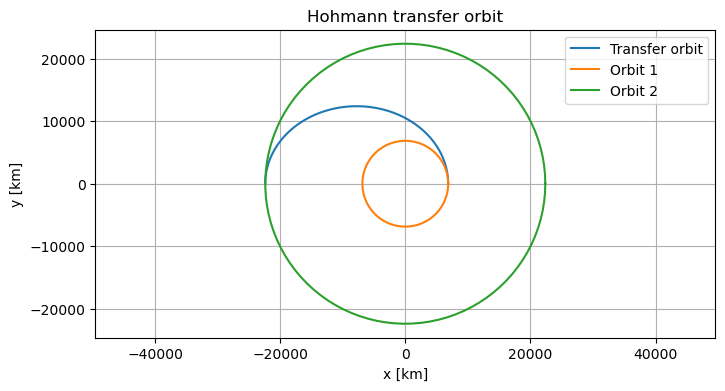

In [15]:
pio.renderers.default = "png"
plt.figure(figsize=(8, 4))
plt.plot(rs[:,0], rs[:,1], label='Transfer orbit')
plt.plot(r1xs, r1ys, label='Orbit 1')
plt.plot(r2xs, r2ys, label='Orbit 2')

plt.title("Hohmann transfer orbit")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()
plt.show()

***Note:*** Add the phasing experiment; it may be Example 6.4.

## Coaxial Transfer

A 2000-kg spacecraft is in a 480-km by 800-km Earth orbit (Orbit 1). Find:

+ The Δv required at perigee A to place the spacecraft in a 480-km by 16,000-km transfer ellipse (Orbit 2).
+ The Δv (apogee kick) required at B of the transfer orbit to establish a circular orbit at 16,000-km altitude (Orbit 3).
+ The total propellant required if the specific impulse is 300 s.

In [16]:
I_sp = 300
g0 = 9.81
m = 2000

The simulation is created:

In [17]:
sim1 = rb.Simulation()
sim1.units = 'km', 's', 'kg'

In [18]:
mu = pc.constantes.G * pc.constantes.M_earth / 1e9      # In km^3 / s^2

The orbit radii are defined:

+ For Orbit 1:

In [19]:
rp_1 = 6378 + 480
ra_1 = 6378 + 6000

In [20]:
a1 = (rp_1 + ra_1) / 2

In [21]:
e1 = (ra_1 - rp_1) / (ra_1 + rp_1)

In [22]:
e1

0.28696194635059263

+ For Orbit 2:

In [23]:
r2 = 6378 + 16000

+ For the perigee-to-$r_2$ transfer orbit:

In [24]:
rp_3 = rp_1
ra_3 = r2

+ For the apogee-to-$r_2$ transfer orbit:
***Note:*** The notation _t will be used.

In [25]:
rp_3t = ra_1
ra_3t = r2

In [26]:
a3 = (rp_3 + ra_3) / 2
a3t = (rp_3t + ra_3t) / 2

In [27]:
e3 = (r2 - rp_3) / (r2 + rp_3)
e3t = (r2 - rp_3t) / (r2 + rp_3t)

Defining a function for angular momentum:

In [28]:
def h(mu, rp, ra):
  h = ((2 * mu)**0.5) * ((rp * ra) / (rp + ra))**0.5
  return h

In [29]:
h_1 = h(mu, rp_1, ra_1)
h_2 = h(mu, r2, r2)
h_3 = h(mu, rp_3, ra_3)
h_3t = h(mu, rp_3t, ra_3t)

In [30]:
print(f"Angular momentum of Orbit 1: {h_1:.2f}")
print(f"Angular momentum of Orbit 2: {h_2:.2f}")
print(f"Angular momentum of transfer orbit 1: {h_3:.2f}")
print(f"Angular momentum of transfer orbit 2: {h_3t:.2f}")

Angular momentum of Orbit 1: 59313.08
Angular momentum of Orbit 2: 94445.12
Angular momentum of transfer orbit 1: 64689.57
Angular momentum of transfer orbit 2: 79708.54


Velocities:

In [31]:
def velocidades(mu, r_salida, r_llegada, h1, h2, h3):
  va1 = h1 / r_salida
  va3 = h3 / r_salida

  vb2 = h2 / r_llegada
  vb3 = h3 / r_llegada

  return va1, va3, vb2, vb3

The function is called to determine the different velocities:

In [32]:
va_1, va_3, vb_2, vb_3 = velocidades(mu, rp_1, r2, h_1, h_2, h_3)

In [33]:
va_1t, va_3t, vb_2t, vb_3t = velocidades(mu, ra_1, r2, h_1, h_2, h_3t)

With the velocities available, their changes can be determined:

In [34]:
def delta_vs(va1, va3, vb2, vb3):
  delta_va = va3 - va1
  delta_vb = vb2 - vb3
  delta_total = delta_va + delta_vb
  return delta_va, delta_vb, delta_total

In [35]:
delta_v_a, delta_v_b, delta_total = delta_vs(va_1, va_3, vb_2, vb_3)

In [36]:
print(f"Delta v at point A: {delta_v_a:.2f} km/s")
print(f"Delta v at point B: {delta_v_b:.2f} km/s")
print(f"Total delta v: {delta_total:.2f} km/s")

Delta v at point A: 0.78 km/s
Delta v at point B: 1.33 km/s
Total delta v: 2.11 km/s


In [37]:
delta_v_at, delta_v_bt, delta_totalt = delta_vs(va_1t, va_3t, vb_2t, vb_3t)

In [38]:
print(f"Delta v at point A: {delta_v_at:.2f} km/s")
print(f"Delta v at point B: {delta_v_bt:.2f} km/s")
print(f"Total delta v: {delta_totalt:.2f} km/s")

Delta v at point A: 1.65 km/s
Delta v at point B: 0.66 km/s
Total delta v: 2.31 km/s


To finish the example, the propellant mass is calculated:

In [39]:
def masa_requerida (delta_v, I_sp, g0, m):
  delta_m_m = 1  - np.exp( -(delta_v * 1000)  / (I_sp * g0))
  delta_m = delta_m_m * m
  return delta_m_m, delta_m

In [40]:
delta_m_m, delta_m = masa_requerida(delta_total, I_sp, g0, m)
delta_m_mt, delta_mt = masa_requerida(delta_totalt, I_sp, g0, m)

In [41]:
print(f"Mass ratio in the first transfer: {delta_m_m:.2f}")
print(f"Propellant mass consumed: {delta_m:.2f} kg")

Mass ratio in the first transfer: 0.51
Propellant mass consumed: 1024.74 kg


In [42]:
print(f"Mass ratio in the second transfer: {delta_m_mt:.2f}")
print(f"Propellant mass consumed: {delta_mt:.2f} kg")

Mass ratio in the second transfer: 0.54
Propellant mass consumed: 1086.52 kg


To use Rebound, the transfer times must be determined:

In [43]:
def t_hohmann(mu, a):
  t = (1 / 2) * ((4 * np.pi**2 * a**3) / (mu))**0.5
  return t

In [44]:
th1 = t_hohmann(mu, a3)
tht = t_hohmann(mu, a3t)

In [45]:
print(f"Transfer time 1: {th1:.2f} s")
print(f"Transfer time 2: {tht:.2f} s")

Transfer time 1: 8794.54 s
Transfer time 2: 11399.37 s


The bodies are added to the simulation:

In [46]:
sim1.add(m=pc.constantes.M_earth)
sim1.add(m=0, x=rp_3, y=0, z=0, vx=0, vy=va_3, vz=0)

The lists for storing the data are created, and the integration loop is run:

In [47]:
Nt = 100

ts1 = np.linspace(0, th1, Nt)

In [48]:
rs1 = np.zeros((Nt, 3))
vs1 = np.zeros((Nt, 3))

In [49]:
for i, t in enumerate(ts1):
  sim1.integrate(t)
  rs1[i] = sim1.particles[1].xyz

The procedure is repeated for transfer 2:

In [50]:
sim2 = rb.Simulation()
sim2.units = 'km', 's', 'kg'

sim2.add(m=pc.constantes.M_earth)
sim2.add(m=0, x=-rp_3t, y=0, z=0, vx=0, vy=-va_3t, vz=0)

ts2 = np.linspace(0, tht, Nt)
rs2 = np.zeros((Nt, 3))
vs2 = np.zeros((Nt, 3))

for i, t in enumerate(ts2):
  sim2.integrate(t)
  rs2[i] = sim2.particles[1].xyz

* For the original orbits:

In [51]:
thetas = np.linspace(0, 2 * np.pi, 100)

rs_elipse = a1 * (1 - e1**2) / (1 + e1 * np.cos(thetas))
xs_elipse = rs_elipse * np.cos(thetas)
ys_elipse = rs_elipse * np.sin(thetas)

r2xs = r2 * np.cos(thetas)
r2ys = r2 * np.sin(thetas)

Finally, the orbits are plotted:

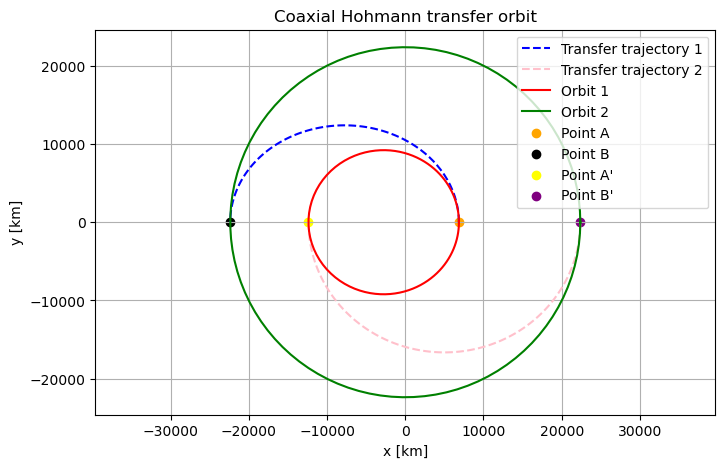

In [52]:
pio.renderers.default = "png"
plt.figure(figsize=(8, 5))
plt.plot(rs1[:,0], rs1[:,1],
         color="blue", linestyle="--",
         label="Transfer trajectory 1")

plt.plot(rs2[:,0], rs2[:,1],
         color="pink", linestyle="--",
         label="Transfer trajectory 2")

plt.plot(xs_elipse, ys_elipse,
         color="red", linestyle="-",
         label="Orbit 1")
plt.plot(r2xs, r2ys,
         color="green", linestyle="-",
         label="Orbit 2")

plt.scatter(rp_1, 0, color="orange", label="Point A")
plt.scatter(-r2, 0, color="black", label="Point B")

plt.scatter(-ra_1, 0, color="yellow", label="Point A'")
plt.scatter(r2, 0, color="purple", label="Point B'")


plt.title("Coaxial Hohmann transfer orbit")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()

## Bielliptic Transfer

Find the total delta-v requirement for a bielliptic Hohmann transfer from a geocentric circular orbit of 7000-km radius to one of 105,000-km radius. Let the apogee of the first ellipse be 210,000 km.

Compare the delta-v schedule and total flight time with those for an ordinary single Hohmann transfer ellipse.

In [53]:
ra_bi = 7000       # In km
rb_bi = 210000     # In km
rc_bi = 105000     # In km
rd_bi = rc_bi

In [54]:
mu = pc.constantes.G * pc.constantes.M_earth / 1e9      # In km^3 / s^2

In [55]:
va_bi_1 = (mu / ra_bi)**0.5

In [56]:
print(f"The circular velocity is: {va_bi_1:.3f} km/s")

The circular velocity is: 7.546 km/s


In [57]:
t_bi_1 = 2 * np.pi * (ra_bi**3 / mu)**0.5

Now the angular momentum for Orbit 2:

In [58]:
h_bi_2 = h(mu, ra_bi, rb_bi)

In [59]:
print(f"The angular momentum of Orbit 2 is: {h_bi_2:.0f} km^2/s")

The angular momentum of Orbit 2 is: 73487 km^2/s


***Note:*** Reusing the functions defined in the previous section.

In [60]:
va_bi_2 = h_bi_2 / ra_bi
vb_bi_2 = h_bi_2 / rb_bi

In [61]:
print(f"The velocity of Orbit 2 at A is: {va_bi_2:.3f} km/s")
print(f"The velocity of Orbit 2 at B is: {vb_bi_2:.3f} km/s")

The velocity of Orbit 2 at A is: 10.498 km/s
The velocity of Orbit 2 at B is: 0.350 km/s


The procedure is repeated for Orbit 3:

In [62]:
h_bi_3 = h(mu, rb_bi, rc_bi)

In [63]:
print(f"The angular momentum of Orbit 3 is: {h_bi_3:.0f} km^2/s")

The angular momentum of Orbit 3 is: 236229 km^2/s


In [64]:
vb_bi_3 = h_bi_3 / rb_bi
vc_bi_3 = h_bi_3 / rc_bi

In [65]:
print(f"The velocity of Orbit 3 at B is: {vb_bi_3:.4f} km/s")
print(f"The velocity of Orbit 3 at C is: {vc_bi_3:.4f} km/s")

The velocity of Orbit 3 at B is: 1.1249 km/s
The velocity of Orbit 3 at C is: 2.2498 km/s


For Orbit 4:

In [66]:
vc_bi_4 = (mu / rc_bi)**0.5
vd_bi_4 = (mu / rd_bi)**0.5

In [67]:
print(f"The velocity of Orbit 4 at C and D is: {vc_bi_4:.4f} km/s")

The velocity of Orbit 4 at C and D is: 1.9484 km/s


In [68]:
t_bi_4 = 2 * np.pi * (rc_bi**3 / mu)**0.5

Then $Δv$ is found for the bielliptic orbit, along with its corresponding transfer time:

In [69]:
def deltas_vs_bi(v_bi_1, v_bi_2):
  delta_v_bi = np.abs(v_bi_2 - v_bi_1)
  return delta_v_bi

In [70]:
delta_va_bi = deltas_vs_bi(va_bi_1, va_bi_2)
delta_vb_bi = deltas_vs_bi(vb_bi_2, vb_bi_3)
delta_vc_bi = deltas_vs_bi(vc_bi_3, vc_bi_4)

In [71]:
delta_v_bi_total = delta_va_bi + delta_vb_bi + delta_vc_bi

In [72]:
print(f"The bielliptic delta v is: {delta_v_bi_total:.4f} km/s")

The bielliptic delta v is: 4.0285 km/s


In [73]:
a_bi_2 = (ra_bi + rb_bi) / 2
a_bi_3 = (rb_bi + rc_bi) / 2

In [74]:
print(f"The semi-major axis of Orbit 2 is: {a_bi_2:.0f} km")
print(f"The semi-major axis of Orbit 3 is: {a_bi_3:.0f} km")

The semi-major axis of Orbit 2 is: 108500 km
The semi-major axis of Orbit 3 is: 157500 km


In [75]:
t_bi =(1 / 2) *(2 * np.pi) / (mu**0.5) * ( a_bi_2**1.5 + a_bi_3**1.5)

In [76]:
print(f"The bielliptic transfer time is: {t_bi:.0f} s")

The bielliptic transfer time is: 488868 s


In [77]:
h_bi_5 = h(mu, ra_bi, rd_bi)

In [78]:
print(f"The angular momentum of Orbit 5 is: {h_bi_5:.0f} km^2/s")

The angular momentum of Orbit 5 is: 72330 km^2/s


In [79]:
va_bi_5 = h_bi_5 / ra_bi
vd_bi_5 = h_bi_5 / rd_bi

In [80]:
print(f"The velocity of Orbit 5 at A is: {va_bi_5:.4f} km/s")
print(f"The velocity of Orbit 5 at D is: {vd_bi_5:.4f} km/s")

The velocity of Orbit 5 at A is: 10.3329 km/s
The velocity of Orbit 5 at D is: 0.6889 km/s


In [81]:
delta_va_bi_h = deltas_vs_bi(va_bi_1, va_bi_5)
delta_vd_bi_h = deltas_vs_bi(vc_bi_4, vd_bi_5)

In [82]:
delta_v_bi_h = delta_va_bi_h + delta_vd_bi_h

In [83]:
print(f"The Hohmann delta v is: {delta_v_bi_h:.4f} km/s")

The Hohmann delta v is: 4.0463 km/s


In [84]:
a_bi_5 = (ra_bi + rd_bi) / 2

In [85]:
t_bi_h = (np.pi / mu**0.5) * a_bi_5**1.5

The first simulation is initialized:

In [86]:
Nt = 200

In [87]:
def simulations(mu, x, vy, t_sim):
  sim = rb.Simulation()
  sim.units = 'km', 's', 'kg'

  sim.add(m=pc.constantes.M_earth)
  sim.add(m=0, x=x, y=0, z=0, vx=0, vy=vy, vz=0)

  ts = np.linspace(0, t_sim, Nt)
  rs = np.zeros((Nt, 3))
  vs = np.zeros((Nt, 3))

  for i, t in enumerate(ts):
    sim.integrate(t)
    rs[i] = sim.particles[1].xyz

  return sim, rs

In [88]:
sim_bi_1, rs_bi_1 = simulations(mu, ra_bi, va_bi_1, t_bi_1)

In [89]:
sim_bi_2, rs_bi_2 = simulations(mu, ra_bi, va_bi_2, t_bi*0.35)

In [90]:
sim_bi_3, rs_bi_3 = simulations(mu, -rb_bi, -vb_bi_3, t_bi*0.65)

In [91]:
sim_bi_4, rs_bi_4 = simulations(mu, rc_bi, vd_bi_4, t_bi_4)

In [92]:
sim_bi_5, rs_bi_5 = simulations(mu, ra_bi, va_bi_5, t_bi_h)

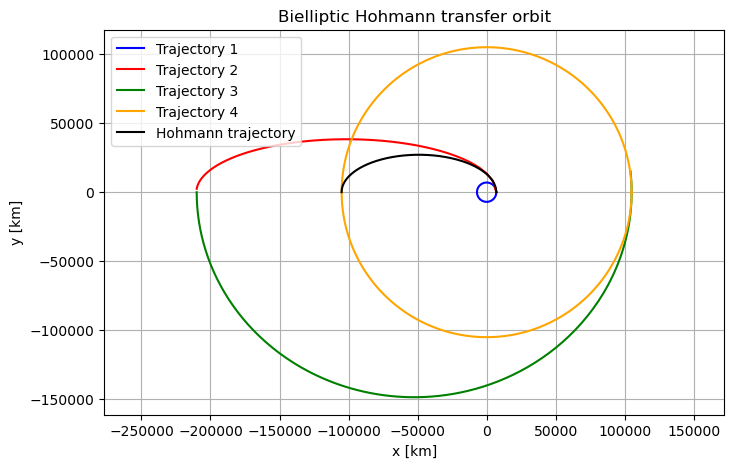

In [93]:
pio.renderers.default = "png"
plt.figure(figsize=(8, 5))

plt.plot(rs_bi_1[:,0], rs_bi_1[:,1],
         color="blue", linestyle="-",
         label="Trajectory 1")

plt.plot(rs_bi_2[:,0], rs_bi_2[:,1],
         color="red", linestyle="-",
         label="Trajectory 2")

plt.plot(rs_bi_3[:,0], rs_bi_3[:,1],
         color="green", linestyle="-",
         label="Trajectory 3")

plt.plot(rs_bi_4[:,0], rs_bi_4[:,1],
         color="orange", linestyle="-",
         label="Trajectory 4")

plt.plot(rs_bi_5[:,0], rs_bi_5[:,1],
         color="black", linestyle="-",
         label="Hohmann trajectory")


plt.title("Bielliptic Hohmann transfer orbit")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()

## Phasing Maneuver

Spacecraft at A and B are in the same orbit (1).

At the instant shown in Fig. 6.11, the chaser vehicle at A executes a phasing maneuver so as to catch the target spacecraft back at A after just one revolution of the chaser's phasing orbit (2).

What is the required total delta-v?

In [94]:
ra_mf = 6800        # In km
rc_mf = 13600       # In km

In [95]:
h_mf_1 = h(mu, ra_mf, rc_mf)

In [96]:
print(f"The angular momentum of Orbit 1 is: {h_mf_1:.0f} km^2/s")

The angular momentum of Orbit 1 is: 60116 km^2/s


In [97]:
a_mf_1 = (ra_mf + rc_mf) / 2

In [98]:
T_mf_1 = 2 * np.pi * (a_mf_1**3 / mu)**0.5

In [99]:
e_mf_1 = (rc_mf - ra_mf) / (rc_mf + ra_mf)

In [100]:
print(f"The period of Orbit 1 is: {T_mf_1:.0f} s")
print(f"The eccentricity of Orbit 1 is: {e_mf_1:.4f}")

The period of Orbit 1 is: 10252 s
The eccentricity of Orbit 1 is: 0.3333


The eccentric anomaly at point B must be calculated:

In [101]:
theta_mf_b = np.deg2rad(90)

In [102]:
E_mf_b = 2 * np.arctan(((1 - e_mf_1) / (1 + e_mf_1))**0.5
                       * np.tan(theta_mf_b / 2))

$$
t_{AB} = \frac{T_1}{2\pi} (E_B - e_1\sin E_B)
$$

In [103]:
t_mf_ab = (T_mf_1 / (2 * np.pi)) * (E_mf_b - e_mf_1 * np.sin(E_mf_b))

In [104]:
print(f"The flight time from Orbit A to B is: {t_mf_ab:.1f} s")

The flight time from Orbit A to B is: 1495.7 s


At this point, the period of Orbit 2 can be calculated. It must equal the time required for the target vehicle to travel from point B to point A in Orbit 1.

In [105]:
T_mf_2 = T_mf_1 - t_mf_ab

In [106]:
print(f"The period of Orbit 2 is: {T_mf_2:.1f} s")

The period of Orbit 2 is: 8756.3 s


This gives the semi-major axis of Orbit 2, the distance to D, and the angular momentum in Orbit 2.

In [107]:
a_mf_2 = ((mu**0.5) * T_mf_2 / (2 * np.pi) )**(2/3)

In [108]:
rd_mf = 2 * a_mf_2 - ra_mf

In [109]:
h_mf_2 = h(mu, ra_mf, rd_mf)

In [110]:
print(f"The distance to D in Orbit 2 is: {rd_mf:.0f} km")
print(f"The angular momentum of Orbit 2 is: {h_mf_2:.0f} km^2/s")

The distance to D in Orbit 2 is: 11564 km
The angular momentum of Orbit 2 is: 58426 km^2/s


The velocities and their changes are then calculated:

In [111]:
va_mf_1 = h_mf_1 / ra_mf
va_mf_2 = h_mf_2 / ra_mf

In [112]:
# To enter Orbit 2
delta_va_mf_r = va_mf_2 - va_mf_1

# To return to Orbit 1
delta_va_mf = va_mf_1 - va_mf_2

In [113]:
# To reach the target
delta_va_mf_total = np.abs(delta_va_mf) + np.abs(delta_va_mf_r)

In [114]:
print(f"The delta v required to reach the target is: "
      f"{delta_va_mf_total:.4f} km/s")

The delta v required to reach the target is: 0.4970 km/s


In [115]:
sim_mf_1, rs_mf_1 = simulations(mu, ra_mf, va_mf_1, T_mf_1)

In [116]:
sim_mf_2, rs_mf_2 = simulations(mu, ra_mf, va_mf_2, T_mf_2)

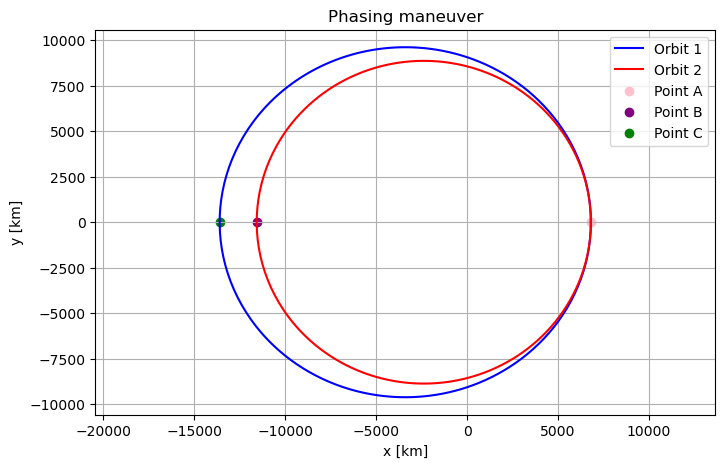

In [117]:
pio.renderers.default = "png"
plt.figure(figsize=(8, 5))

plt.plot(rs_mf_1[:,0], rs_mf_1[:,1],
         color="blue", linestyle="-",
         label="Orbit 1")

plt.plot(rs_mf_2[:,0], rs_mf_2[:,1],
         color="red", linestyle="-",
         label="Orbit 2")

plt.scatter(ra_mf, 0, color="pink", label="Point A")
plt.scatter(-rd_mf, 0, color="purple", label="Point B")
plt.scatter(-rc_mf, 0, color="green", label="Point C")

plt.title("Phasing maneuver")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()